## Import Dependencies

In [3]:
import os
import glob
import csv
import time
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.cuda.amp import GradScaler, autocast # For Mixed Precision (Speed)

## Model Execution

In [ ]:
# 1. CONFIGURATION
Config = {
    "CLUSTER_IMAGE_ROOT": "/Users/laythmarabeh/Documents/UCSD/288R/Data/archive/images", # CHANGE TO LOCAL DATA ROOT
    
    "CSV_FILE": "Data_Entry_2017.csv",
    "SPLIT_FILE": "train_val_list.txt",
    
    # Hyperparameters
    "IMG_SIZE": 224,
    "BATCH_SIZE": 16,          # High batch size for GPU
    "LEARNING_RATE": 1e-4,
    "EPOCHS": 20,
    "PATIENCE": 5,             # Early stopping
    "NUM_WORKERS": 0,          # Use 16 if GPU access is available
    
    # Outputs
    "LOG_FILE": "training_log.csv",
    "BEST_MODEL_FILE": "densenet_best.pth",
    "CHECKPOINT_FILE": "densenet_checkpoint.pth"
}

# Auto-detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available(): device = torch.device("mps")
print(f"🚀 Launching on device: {device}")


# 2. PATH MAPPING (CRITICAL FOR SPLIT FOLDERS)
def create_path_map(root_dir):
    """
    Scans images_001, images_002, etc. and creates a map:
    {'000001_000.png': '/path/to/images_001/images/000001_000.png'}
    """
    print(f"Scanning for images in {root_dir}...")
    # Look recursively for .png files in all subfolders
    image_paths = glob.glob(os.path.join(root_dir, "**", "*.png"), recursive=True)
    
    path_map = {os.path.basename(p): p for p in image_paths}
    print(f"✅ Found {len(path_map)} images across subfolders.")
    return path_map

# 3. DATASET CLASS
class NIHDataset(Dataset):
    def __init__(self, dataframe, path_map, transform=None, classes=None):
        self.df = dataframe
        self.path_map = path_map
        self.transform = transform
        self.classes = classes
        
        # Parse labels
        self.df['labels_list'] = self.df['Finding Labels'].apply(
            lambda x: [] if 'No Finding' in x else x.split('|')
        )
        
        # Create Multi-Hot Encoding
        from sklearn.preprocessing import MultiLabelBinarizer
        if self.classes is None:
            self.mlb = MultiLabelBinarizer()
            self.labels = self.mlb.fit_transform(self.df['labels_list'])
            self.classes = self.mlb.classes_
        else:
            self.mlb = MultiLabelBinarizer(classes=self.classes)
            self.labels = self.mlb.fit_transform(self.df['labels_list'])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['Image Index']
        
        # USE THE MAP TO FIND THE FILE
        if img_name in self.path_map:
            img_path = self.path_map[img_name]
        else:
            # Fallback
            print(f"⚠️ Warning: {img_name} not found in path map.")
            return torch.zeros((3, Config["IMG_SIZE"], Config["IMG_SIZE"])), torch.tensor(self.labels[idx], dtype=torch.float32)

        # Image Load using OpenCV
        image = cv2.imread(img_path)
        if image is None:
            return torch.zeros((3, Config["IMG_SIZE"], Config["IMG_SIZE"])), torch.tensor(self.labels[idx], dtype=torch.float32)

        # CLAHE
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        image = clahe.apply(gray)
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        
        image = Image.fromarray(image)
        
        if self.transform:
            image = self.transform(image)
            
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label

# Transform: Letterbox Padding
class LetterboxPad:
    def __call__(self, image):
        w, h = image.size
        target = Config["IMG_SIZE"]
        scale = min(target / w, target / h)
        new_w, new_h = int(w * scale), int(h * scale)
        image = image.resize((new_w, new_h), Image.Resampling.BICUBIC)
        new_img = Image.new("RGB", (target, target), (0, 0, 0))
        new_img.paste(image, ((target - new_w) // 2, (target - new_h) // 2))
        return new_img

# 4. TRAIN & VALIDATE ENGINES

def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    running_loss = 0.0
    steps = len(loader)
    
    for i, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Mixed Precision 
        if device.type == 'cuda':
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            # Standard float32 for CPU/MPS
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        running_loss += loss.item()
        
        if i % 100 == 0:
            print(f"\rStep [{i}/{steps}] Loss: {loss.item():.4f}", end="")
            
    return running_loss / steps

def validate(model, loader, criterion, device, class_names):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            # Store probabilities
            preds = torch.sigmoid(outputs)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            
    avg_loss = running_loss / len(loader)
    
    # Stack and Calc AUC
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    try:
        # Macro average treats all classes equally (good for imbalance)
        auc_score = roc_auc_score(all_labels, all_preds, average='macro')
    except ValueError:
        auc_score = 0.0
        print("Warning: AUC calc failed (likely missing class in batch).")

    metrics = {'Mean_AUC': auc_score}
    return avg_loss, metrics

# 5. MAIN EXECUTION
def main():
    # GENERATE PATH MAP
    path_map = create_path_map(Config["CLUSTER_IMAGE_ROOT"])
    if len(path_map) == 0:
        print("❌ Error: No images found. Check CLUSTER_IMAGE_ROOT path!")
        return

    # LOAD DATA
    full_df = pd.read_csv(Config["CSV_FILE"])
    
    # Filter using Train/Val List text file
    with open(Config["SPLIT_FILE"], 'r') as f:
        train_val_list = [line.strip() for line in f.readlines()]
    full_df = full_df[full_df['Image Index'].isin(train_val_list)]
    
    # Filter: Only keep images we actually found on disk
    full_df = full_df[full_df['Image Index'].isin(path_map.keys())]
    
    # Patient-Level Split
    patient_ids = full_df['Patient ID'].unique()
    # Fixed seed for reproducibility
    np.random.seed(42) 
    train_ids, val_ids = np.split(np.random.permutation(patient_ids), [int(.8*len(patient_ids))])
    
    train_df = full_df[full_df['Patient ID'].isin(train_ids)]
    val_df = full_df[full_df['Patient ID'].isin(val_ids)]
    
    print(f"Train Size: {len(train_df)} | Val Size: {len(val_df)}")

    # 3. SETUP DATA LOADERS
    train_tf = transforms.Compose([
        LetterboxPad(),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    val_tf = transforms.Compose([
        LetterboxPad(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    nih_classes = sorted(['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 
                          'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 
                          'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'])

    # Pass the PATH_MAP to the dataset
    train_ds = NIHDataset(train_df, path_map, transform=train_tf, classes=nih_classes)
    val_ds = NIHDataset(val_df, path_map, transform=val_tf, classes=nih_classes)

    train_loader = DataLoader(train_ds, batch_size=Config["BATCH_SIZE"], 
                              shuffle=True, num_workers=Config["NUM_WORKERS"], pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=Config["BATCH_SIZE"], 
                             shuffle=False, num_workers=Config["NUM_WORKERS"], pin_memory=True)

    # MODEL SETUP
    print("Building DenseNet-121...")
    model = models.densenet121(weights='DEFAULT')
    model.classifier = nn.Linear(model.classifier.in_features, len(nih_classes))
    model = model.to(device)

    # Weighted Loss
    pos_counts = train_ds.labels.sum(axis=0)
    # Prevent div by zero
    pos_weights = (len(train_df) - pos_counts) / (pos_counts + 1e-5)
    pos_weights = torch.tensor(pos_weights, dtype=torch.float32).to(device)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
    optimizer = optim.AdamW(model.parameters(), lr=Config["LEARNING_RATE"])
    
    # Mixed Precision Scaler
    scaler = GradScaler()

    # TRAINING LOOP
    best_auc = 0.0
    patience_counter = 0

    # Initialize CSV
    if not os.path.exists(Config["LOG_FILE"]):
        with open(Config["LOG_FILE"], 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['epoch', 'train_loss', 'val_loss', 'mean_auc'])

    print("Starting Training...")
    
    try: 
        for epoch in range(Config["EPOCHS"]):
            print(f"\n[Epoch {epoch+1}/{Config['EPOCHS']}]")
            
            # Train & Validate
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler)
            val_loss, metrics = validate(model, val_loader, criterion, device, nih_classes)
            
            current_auc = metrics.get('Mean_AUC', 0)
            
            print(f"\nResults -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Mean AUC: {current_auc:.4f}")
            
            # Log to CSV
            with open(Config["LOG_FILE"], 'a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([epoch+1, train_loss, val_loss, current_auc])
            
            # Checkpointing (Best Model)
            if current_auc > best_auc:
                best_auc = current_auc
                patience_counter = 0
                torch.save(model.state_dict(), Config["BEST_MODEL_FILE"])
                print(f"🥇 New Best AUC! Saved to {Config['BEST_MODEL_FILE']}")
            else:
                patience_counter += 1
                print(f"No improvement. Patience: {patience_counter}/{Config['PATIENCE']}")
            
            # Save Latest Backup
            torch.save(model.state_dict(), "densenet_latest_backup.pth")

            # Early Stopping
            if patience_counter >= Config["PATIENCE"]:
                print("Early Stopping Triggered.")
                break

    except KeyboardInterrupt:
        print("\n🛑 Manual Interruption (Ctrl+C) Detected!")
        print("Saving current model state before exiting...")
        torch.save(model.state_dict(), "densenet_EMERGENCY_SAVE.pth")
        print("Safe to close.")
            
    print(f"Done. Best AUC: {best_auc:.4f}")

if __name__ == "__main__":
    main()

🚀 Launching on device: mps
Scanning for images in /Users/laythmarabeh/Documents/UCSD/288R/Data/archive/images...
✅ Found 97418 images across subfolders.
Train Size: 60628 | Val Size: 15379
Building DenseNet-121...


/var/folders/jn/py03l5td6rj7_ndqgf05g49r0000gn/T/ipykernel_58293/2205187832.py:282: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Starting Training...

[Epoch 1/20]
Step [0/3790] Loss: 1.1238

libpng error: Read Error


Step [700/3790] Loss: 0.9217

...

Step [3600/3790] Loss: 0.6038

libpng error: Read Error


Step [3700/3790] Loss: 0.6551

libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error



Results -> Train Loss: 0.7403 | Val Loss: 1.1507 | Mean AUC: 0.8134
No improvement. Patience: 5/5
Early Stopping Triggered.
Done. Best AUC: 0.8242


## Model Performance 

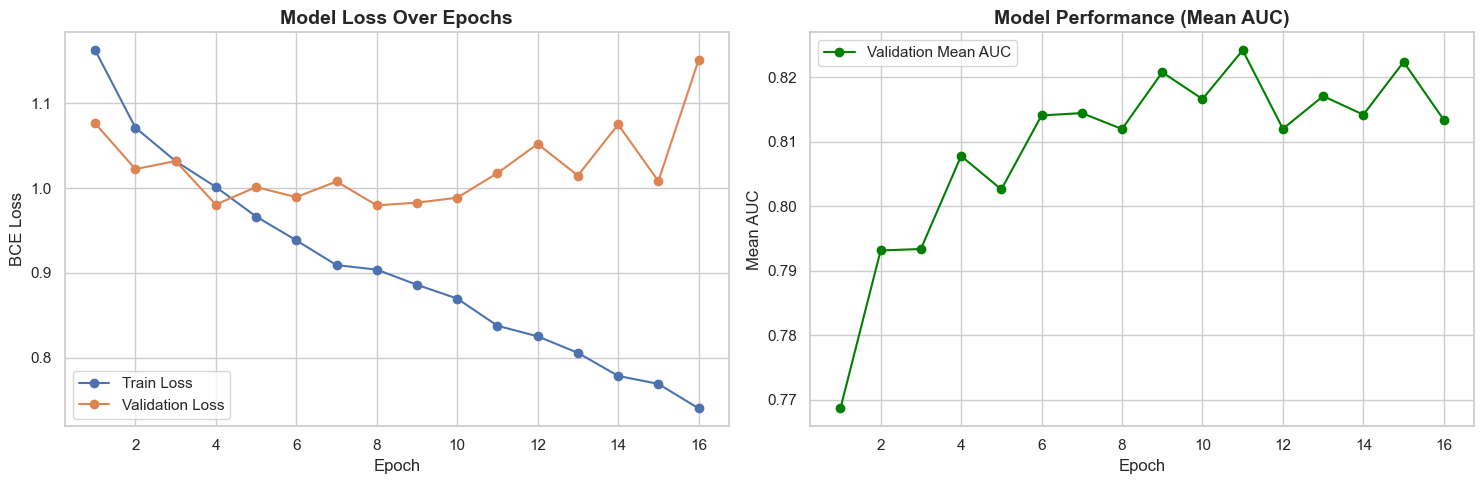

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
log_df = pd.read_csv("training_log.csv")

# Set up the figure
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Loss Curve
ax1.plot(log_df['epoch'], log_df['train_loss'], label='Train Loss', marker='o')
ax1.plot(log_df['epoch'], log_df['val_loss'], label='Validation Loss', marker='o')
ax1.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend()

# Plot 2: Mean AUC Curve
ax2.plot(log_df['epoch'], log_df['mean_auc'], label='Validation Mean AUC', color='green', marker='o')
ax2.set_title('Model Performance (Mean AUC)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean AUC')
ax2.legend()

plt.tight_layout()
plt.show()
# Tip: Right-click the output graph and "Save Image As" for your slides.

## Detailed Metrics (Run all cells below if kernel is reloaded)

In [ ]:
# 1. Config & Paths 
IMAGE_ROOT = "/Users/laythmarabeh/Documents/UCSD/288R/Data/archive/images" # CHANGE TO LOCAL DATA ROOT
CSV_FILE = "/Users/laythmarabeh/Documents/UCSD/288R/NIH-XRay-Segmentation/Data_Entry_2017.csv"
SPLIT_FILE = "train_val_list.txt"
IMG_SIZE = 224
BATCH_SIZE = 16

nih_classes = sorted(['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 
                      'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 
                      'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'])

# 2. Rebuild the Path Map
def create_path_map(root_dir):
    print("Mapping image paths...")
    image_paths = glob.glob(os.path.join(root_dir, "**", "*.png"), recursive=True)
    return {os.path.basename(p): p for p in image_paths}

path_map = create_path_map(IMAGE_ROOT)

# 3. Define Dataset and Transforms
class LetterboxPad:
    def __call__(self, image):
        w, h = image.size
        scale = min(IMG_SIZE / w, IMG_SIZE / h)
        new_w, new_h = int(w * scale), int(h * scale)
        image = image.resize((new_w, new_h), Image.Resampling.BICUBIC)
        new_img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        new_img.paste(image, ((IMG_SIZE - new_w) // 2, (IMG_SIZE - new_h) // 2))
        return new_img

class NIHDataset(Dataset):
    def __init__(self, dataframe, path_map, transform=None):
        self.df = dataframe
        self.path_map = path_map
        self.transform = transform
        
        self.df['labels_list'] = self.df['Finding Labels'].apply(
            lambda x: [] if 'No Finding' in x else x.split('|')
        )
        from sklearn.preprocessing import MultiLabelBinarizer
        self.mlb = MultiLabelBinarizer(classes=nih_classes)
        self.labels = self.mlb.fit_transform(self.df['labels_list'])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['Image Index']
        img_path = self.path_map.get(img_name)
        
        if img_path is None:
            return torch.zeros((3, IMG_SIZE, IMG_SIZE)), torch.tensor(self.labels[idx], dtype=torch.float32)

        image = cv2.imread(img_path)
        if image is None:
            return torch.zeros((3, IMG_SIZE, IMG_SIZE)), torch.tensor(self.labels[idx], dtype=torch.float32)

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        image = clahe.apply(gray)
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(self.labels[idx], dtype=torch.float32)

# 4. Load Data and Recreate val_loader
print("Loading validation dataset...")
full_df = pd.read_csv(CSV_FILE)
with open(SPLIT_FILE, 'r') as f:
    train_val_list = [line.strip() for line in f.readlines()]

full_df = full_df[full_df['Image Index'].isin(train_val_list)]
full_df = full_df[full_df['Image Index'].isin(path_map.keys())]

patient_ids = full_df['Patient ID'].unique()
np.random.seed(42) 
_, val_ids = np.split(np.random.permutation(patient_ids), [int(.8*len(patient_ids))])
val_df = full_df[full_df['Patient ID'].isin(val_ids)]

val_tf = transforms.Compose([
    LetterboxPad(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_ds = NIHDataset(val_df, path_map, transform=val_tf)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ val_loader successfully created with {len(val_ds)} validation images!")

Mapping image paths...
Loading validation dataset...
✅ val_loader successfully created with 15379 validation images!


/var/folders/jn/py03l5td6rj7_ndqgf05g49r0000gn/T/ipykernel_14605/2901639914.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['labels_list'] = self.df['Finding Labels'].apply(


In [7]:
# 1. Setup Device and Class Names
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
nih_classes = sorted(['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 
                      'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 
                      'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'])

# 2. Build the Model and Load Best Weights
print("Initializing DenseNet-121 and loading weights...")
model = models.densenet121(weights=None)
model.classifier = nn.Linear(model.classifier.in_features, len(nih_classes))
model.load_state_dict(torch.load("densenet_best.pth", map_location=device))
model = model.to(device)
model.eval()

# 3. Run Inference on Validation Data
all_preds = []
all_labels = []

print("Running inference on validation data... (This might take a minute)")
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs)
        
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# 4. Apply Threshold and Calculate Metrics
THRESHOLD = 0.5
binary_preds = (all_preds >= THRESHOLD).astype(int)

print("\n5. Calculating Metrics on Test Set...")
print("===============================================================================")
print(f"{'Class':<25} {'AUC':>8} {'Precision':>12} {'Recall':>10} {'F1':>10}")
print("-------------------------------------------------------------------------------")

auc_list, prec_list, rec_list, f1_list = [], [], [], []

for i, class_name in enumerate(nih_classes):
    auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
    prec = precision_score(all_labels[:, i], binary_preds[:, i], zero_division=0)
    rec = recall_score(all_labels[:, i], binary_preds[:, i], zero_division=0)
    f1 = f1_score(all_labels[:, i], binary_preds[:, i], zero_division=0)
    
    auc_list.append(auc)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)
    
    print(f"{class_name:<25} {auc:8.4f} {prec:12.4f} {rec:10.4f} {f1:10.4f}")

print("-------------------------------------------------------------------------------")

# 5. Calculate Averages and Overall Accuracy
macro_auc = np.mean(auc_list)
macro_prec = np.mean(prec_list)
macro_rec = np.mean(rec_list)
macro_f1 = np.mean(f1_list)

print(f"{'MACRO AVG':<25} {macro_auc:8.4f} {macro_prec:12.4f} {macro_rec:10.4f} {macro_f1:10.4f}\n")

exact_match = accuracy_score(all_labels, binary_preds)
print(f"Overall (Exact Match) Accuracy: {exact_match:.4f}")

Initializing DenseNet-121 and loading weights...
Running inference on validation data... (This might take a minute)


libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error



5. Calculating Metrics on Test Set...
Class                          AUC    Precision     Recall         F1
-------------------------------------------------------------------------------
Atelectasis                 0.8088       0.2152     0.7217     0.3315
Cardiomegaly                0.8965       0.0814     0.7738     0.1474
Consolidation               0.7886       0.0831     0.6982     0.1485
Edema                       0.8938       0.0662     0.8045     0.1223
Effusion                    0.8836       0.3457     0.7851     0.4800
Emphysema                   0.8839       0.1558     0.5827     0.2458
Fibrosis                    0.7997       0.0592     0.5294     0.1066
Hernia                      0.9513       0.0842     0.8421     0.1531
Infiltration                0.7202       0.2522     0.6692     0.3663
Mass                        0.8223       0.1151     0.7447     0.1993
Nodule                      0.7367       0.1201     0.5880     0.1994
Pleural_Thickening          0.7850       

## Grad-CAM

Initializing DenseNet-121 and loading weights...
Image 14609 is 'No Finding'. Visualizing the model's highest guess.
Displaying Image Index: 14609 | Target Disease: Effusion


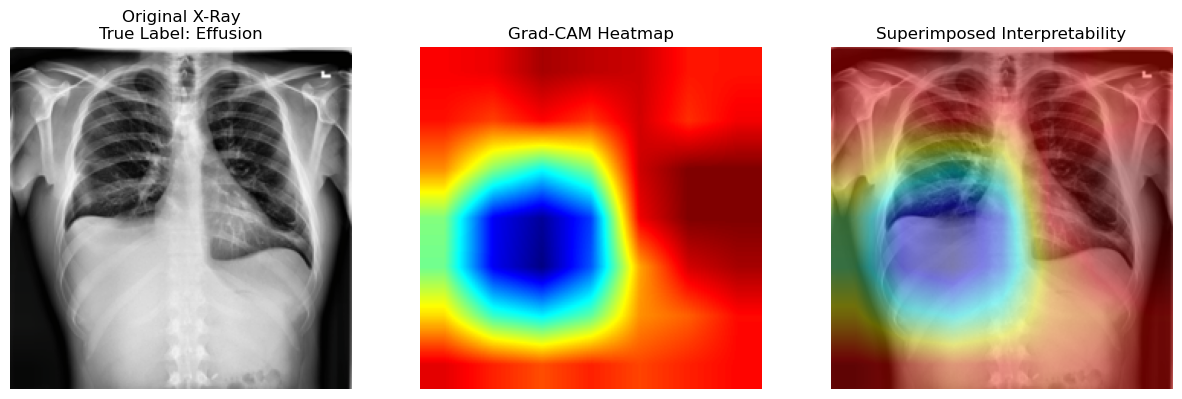

In [31]:
import torch
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
# 1. Setup Device and Class Names
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
nih_classes = sorted(['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 
                      'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 
                      'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'])

# 2. Build the Model and Load Best Weights
print("Initializing DenseNet-121 and loading weights...")
model = models.densenet121(weights=None)
model.classifier = nn.Linear(model.classifier.in_features, len(nih_classes))
model.load_state_dict(torch.load("densenet_best.pth", map_location=device))
model = model.to(device)
model.eval()

def custom_forward(x):
    features = model.features(x)
    out = F.relu(features, inplace=False) # 
    out = F.adaptive_avg_pool2d(out, (1, 1))
    out = torch.flatten(out, 1)
    out = model.classifier(out)
    return out

# Apply the patch to our loaded model
model.forward = custom_forward

class DenseNetGradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        
        # Hook into the final feature block
        target_layer = self.model.features
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_image, target_class_idx):
        self.model.eval()
        self.model.zero_grad()
        
        # Forward pass
        output = self.model(input_image)
        score = output[:, target_class_idx]
        
        # Backward pass
        score.backward(retain_graph=True)
        
        # Pool the gradients and weight the activations
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # Clone activations so we don't modify them in place
        weighted_activations = self.activations.clone()
        for i in range(weighted_activations.shape[1]):
            weighted_activations[:, i, :, :] *= pooled_gradients[i]
            
        # Create the heatmap
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        
        # Normalize safely
        if torch.max(heatmap) > 0:
            heatmap /= torch.max(heatmap)
            
        return heatmap.cpu().detach().numpy()

# --- RUNNING GRAD-CAM ON A SAMPLE FROM VALIDATION LOADER ---
import random

# --- RUNNING GRAD-CAM ON A RANDOM VALIDATION SAMPLE ---
cam = DenseNetGradCAM(model)

# 1. Pick a random index from the validation dataset
random_idx = random.randint(0, len(val_ds) - 1)
sample_img_raw, sample_label = val_ds[random_idx]

# 2. Add the batch dimension (1, C, H, W) and send to device
sample_img = sample_img_raw.unsqueeze(0).to(device)

# 3. If "No Finding" is the only label visualize the highest activated class instead
if torch.sum(sample_label) == 0:
    print(f"Image {random_idx} is 'No Finding'. Visualizing the model's highest guess.")
    model.eval()
    with torch.no_grad():
        preds = model(sample_img)
    target_idx = torch.argmax(preds).item()
    target_disease = nih_classes[target_idx]
else:
    # Pick the highest true label to visualize
    target_idx = torch.argmax(sample_label).item() 
    target_disease = nih_classes[target_idx]

print(f"Displaying Image Index: {random_idx} | Target Disease: {target_disease}")

# Generate Heatmap
heatmap = cam.generate_heatmap(sample_img, target_idx)

# Format the heatmap for plotting
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Un-normalize the original image for display
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
# Note: we use sample_img_raw here instead of images[0]
orig_img = inv_normalize(sample_img_raw).permute(1, 2, 0).cpu().numpy()
orig_img = np.clip(orig_img, 0, 1)

# Superimpose heatmap onto original X-ray
superimposed = heatmap * 0.4 + (orig_img * 255) * 0.6
superimposed = np.clip(superimposed, 0, 255).astype(np.uint8)

# Plotting the results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(orig_img)
ax1.set_title(f"Original X-Ray\nTrue Label: {target_disease}")
ax2.imshow(heatmap)
ax2.set_title("Grad-CAM Heatmap")
ax3.imshow(superimposed)
ax3.set_title("Superimposed Interpretability")
for ax in [ax1, ax2, ax3]: ax.axis('off')
plt.show()